# Exp FA-LOG-2 — Destino da Energia: Órbitas q-livres e Ganho Espectral

**T. Bandeira · Junho de 2026**
*Série analise-espectral-primos — continuação de Exp FA-LOG-1*

---

## Hipótese central

Após a remoção completa dos fatores $q$ do sinal $R_{\log}$, cada $m = r \cdot q^a$
(com $\gcd(r,q)=1$) tem seu pico espectral deslocado de $f_m$ para $f_r = \log r/(2\pi)$.
O inteiro $q$-livre $r$ é o **atrator** da órbita

$$\mathcal{O}_r = \{r,\; rq,\; rq^2,\; \ldots\} \cap [2, N]$$

**Previsão quantitativa:** como todos os membros chegam *em fase* em $f_r$,
o ganho de amplitude deve ser exatamente proporcional ao tamanho da órbita:

$$\text{ganho}_{\text{prev}}(r) = |\mathcal{O}_r|
= \left\lfloor \log_q\!\left(\tfrac{N}{r}\right) \right\rfloor + 1$$

Este notebook mede $\text{ganho}_{\text{med}}(r) = \text{amp\_depois}(f_r) / \text{amp\_antes}(f_r)$
e verifica se $\text{razão} = \text{ganho\_med}/\text{ganho\_prev} \approx 1$.

**Perguntas respondidas:**
1. O ganho é proporcional a $|\mathcal{O}_r|$ — ou há desvio sistemático?
2. Primos $r \neq q$ e compostos $q$-livres se comportam da mesma forma?
3. Quanto da energia que "sai" das origens chega nos destinos vs se dissolve em fundo?
4. Como a norma $L^2$ do sinal muda — e por quê ela **não** se conserva?


## 1. Setup

Parâmetros idênticos ao Exp FA-LOG-1 para comparabilidade direta.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime
import pandas as pd
import pickle, zipfile, os

# ── Parâmetros (idênticos ao Exp FA-LOG-1) ────────────────────────────────────
N     = 300
DT    = 0.05
T_MAX = 6500.0
W     = 3       # janela de busca de pico (bins)

t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)
print(f'N={N} | T_MAX={T_MAX} | pontos={len(t):,} | Delta_f={freqs[1]:.6f}')

PRIMOS_TESTE = [3, 5, 7]

# ── Paleta ────────────────────────────────────────────────────────────────────
BG      = '#0D0D1A'
C_ORIG  = '#7EB8F7'   # azul    — sinal original
C_REM   = '#F97B6B'   # vermelho — sinal removido
C_DEST  = '#A8E6CF'   # verde   — posições destino (q-livres)
C_FONTE = '#FFB347'   # laranja  — posições origem (multiplos de q)
C_PREV  = '#DDA0DD'   # lila    — linha de previsão y=x
C_GRID  = '#1E1E3A'
C_TEXT  = '#CCCCDD'

# ── Funções auxiliares ────────────────────────────────────────────────────────
def f_de_log(lv):
    """Frequência espectral correspondente a log(m)."""
    return lv / (2 * math.pi)

def amp_em_f(F, f_alvo, w=W):
    """Amplitude máxima em janela de w bins ao redor de f_alvo."""
    idx = np.argmin(np.abs(freqs - f_alvo))
    lo, hi = max(0, idx - w), min(len(F), idx + w)
    return np.max(F[lo:hi])

def espectro(sinal):
    return np.abs(np.fft.rfft(sinal)) * DT

def v_q_m(m, q):
    """Expoente de q na fatoracao de m."""
    v = 0
    while m % q == 0:
        v += 1
        m //= q
    return v

print('Setup concluido.')


N=300 | T_MAX=6500.0 | pontos=129,998 | Delta_f=0.000154
Setup concluido.


## 2. Estrutura de órbitas q-livres

Todo $m \in [2,N]$ pertence a exatamente uma órbita:
$$\mathcal{O}_r = \{r,\; rq,\; rq^2,\; \ldots\} \cap [2,N], \qquad r = m\,/\,q^{v_q(m)}$$

As órbitas **particionam** $[2,N]$ — cada $m$ pertence a exatamente uma delas.

Após remoção completa todos os membros convergem para $f_r$.
Potências puras $q^a$ têm $r = 1$, $\log 1 = 0$: são **descartadas** (perda real de energia).


In [2]:
def orbitas_q(q, N):
    """
    Retorna dict {r: [r, r*q, r*q^2, ...] cap [2,N]}
    para cada inteiro q-livre r em [2,N].
    Exclui r=1 (potencias puras de q, descartadas na remocao).
    """
    orbs = {}
    for r in range(2, N + 1):
        if r % q == 0:
            continue                 # nao e q-livre
        orbit = []
        m = r
        while m <= N:
            orbit.append(m)
            m *= q
        orbs[r] = orbit
    return orbs

# Resumo para cada primo testado
print(f'  q   q-livres   orbitas>=2   max|orbita|')
print(f'  ' + '-'*42)
for q in PRIMOS_TESTE:
    orbs = orbitas_q(q, N)
    n_ge2 = sum(1 for o in orbs.values() if len(o) >= 2)
    mmax  = max(len(o) for o in orbs.values())
    print(f'  q={q}:  {len(orbs):5d} q-livres  |  {n_ge2:4d} orbitas com >=2 membros  |  max={mmax}')

# Top 6 orbitas para q=3
print()
print('Top 6 orbitas para q=3:')
orbs3 = orbitas_q(3, N)
top6  = sorted(orbs3.items(), key=lambda x: (-len(x[1]), -int(isprime(x[0]))))[:6]
for r, orb in top6:
    tipo = 'primo' if isprime(r) else 'comp.'
    print(f'  r={r:>4}  ({tipo})  |orbita|={len(orb)}  {orb}')


  q   q-livres   orbitas>=2   max|orbita|
  ------------------------------------------
  q=3:    199 q-livres  |    66 orbitas com >=2 membros  |  max=5
  q=5:    239 q-livres  |    47 orbitas com >=2 membros  |  max=4
  q=7:    257 q-livres  |    35 orbitas com >=2 membros  |  max=3

Top 6 orbitas para q=3:
  r=   2  (primo)  |orbita|=5  [2, 6, 18, 54, 162]
  r=   5  (primo)  |orbita|=4  [5, 15, 45, 135]
  r=   7  (primo)  |orbita|=4  [7, 21, 63, 189]
  r=  11  (primo)  |orbita|=4  [11, 33, 99, 297]
  r=   4  (comp.)  |orbita|=4  [4, 12, 36, 108]
  r=   8  (comp.)  |orbita|=4  [8, 24, 72, 216]


## 3. Construção dos sinais

**Sinal original:**
$$R_{\log}(t) = \sum_{m=2}^{N} -\frac{\cos(t \cdot \log m)}{\sqrt{\log m}}$$

**Sinal após remoção completa de $q$:**
Para cada $m = r \cdot q^a$, substituímos $\log m \to \log r$.
Se $r = 1$ (potência pura $q^a$): componente descartada.

> ⚠️ Esta célula constrói 4 sinais com ~130 mil pontos cada. No Colab leva ~2–4 min.


In [3]:
print('Construindo R_log original...')
R_log = sum(
    -np.cos(t * math.log(m)) / math.sqrt(math.log(m))
    for m in range(2, N + 1)
)
F_log = espectro(R_log)
norma_orig = np.sqrt(np.mean(R_log**2))
print(f'  R_log pronto. Norma L2 = {norma_orig:.6f}')

def construir_R_removido(q):
    """
    Remoção completa dos fatores q:
      m = r * q^a  -->  log(m) - v_q(m)*log(q) = log(r)
    Potencias puras (r=1, log_novo=0): descartadas.
    """
    R = np.zeros(len(t), dtype=float)
    for m in range(2, N + 1):
        vq      = v_q_m(m, q)
        log_nov = math.log(m) - vq * math.log(q)
        if log_nov > 1e-10:
            R += -np.cos(t * log_nov) / math.sqrt(log_nov)
    return R

sinais_rem    = {}
espectros_rem = {}
for q in PRIMOS_TESTE:
    print(f'Construindo R_removido para q={q}...', end=' ', flush=True)
    R = construir_R_removido(q)
    sinais_rem[q]    = R
    espectros_rem[q] = espectro(R)
    norma_r = np.sqrt(np.mean(R**2))
    print(f'pronto. Norma L2 = {norma_r:.6f}  (ratio={norma_r/norma_orig:.4f})')

print('Todos os sinais prontos.')


Construindo R_log original...
  R_log pronto. Norma L2 = 5.809768
Construindo R_removido para q=3... pronto. Norma L2 = 9.917109  (ratio=1.7070)
Construindo R_removido para q=5... pronto. Norma L2 = 8.497532  (ratio=1.4626)
Construindo R_removido para q=7... pronto. Norma L2 = 7.805307  (ratio=1.3435)
Todos os sinais prontos.


## 4. Tabela principal — ganho previsto vs medido

Para cada inteiro $q$-livre $r \in [2,N]$ e cada primo $q$:

| coluna | significado |
|--------|-------------|
| `ganho_prev` | $\|\mathcal{O}_r\|$ — número de membros da órbita |
| `amp_antes` | amplitude em $f_r$ no sinal original |
| `amp_depois` | amplitude em $f_r$ no sinal removido |
| `ganho_med` | `amp_depois / amp_antes` |
| `razao` | `ganho_med / ganho_prev` → ideal: **1.0** |

**Hipótese:** se os membros da órbita chegam em fase em $f_r$,
então $\text{ganho\_med} \approx |\mathcal{O}_r|$ e razão $\approx 1$.
Desvios refletem interferência do fundo (outros $m$ no sinal que perturbam a amplitude local).

A tabela é salva em `fat_log2_ganho_destino.csv`.


In [4]:
rows = []
for q in PRIMOS_TESTE:
    orbs  = orbitas_q(q, N)
    F_rem = espectros_rem[q]

    for r, orbit in orbs.items():
        f_r        = f_de_log(math.log(r))
        amp_antes  = amp_em_f(F_log, f_r)
        amp_depois = amp_em_f(F_rem,  f_r)
        g_prev     = len(orbit)
        g_med      = amp_depois / amp_antes if amp_antes > 1e-12 else float('nan')
        razao      = g_med / g_prev         if not math.isnan(g_med) else float('nan')

        rows.append({
            'q'          : q,
            'r'          : r,
            'primo_r'    : isprime(r),
            'g_prev'     : g_prev,
            'orbita'     : str(orbit),
            'f_r'        : round(f_r,        5),
            'amp_antes'  : round(amp_antes,   4),
            'amp_depois' : round(amp_depois,  4),
            'g_med'      : round(g_med,  4) if not math.isnan(g_med)  else float('nan'),
            'razao'      : round(razao,  4) if not math.isnan(razao) else float('nan'),
        })

df = pd.DataFrame(rows)
df.to_csv('fat_log2_ganho_destino.csv', index=False)
print('CSV salvo: fat_log2_ganho_destino.csv')
print(f'Total de linhas: {len(df)}')

print()
print('=== Razao medido/previsto por tamanho de orbita (todos q) ===')
print(df.groupby('g_prev')['razao']
        .agg(['mean','std','count'])
        .rename(columns={'mean':'media','std':'dp','count':'n'})
        .round(4))

print()
print('=== Razao por q ===')
print(df.groupby('q')['razao']
        .agg(['mean','std','count'])
        .rename(columns={'mean':'media','std':'dp','count':'n'})
        .round(4))

print()
print('=== Razao: primos vs compostos q-livres, por q ===')
print(df.groupby(['q','primo_r'])['razao']
        .agg(['mean','std'])
        .rename(columns={'mean':'media','std':'dp'})
        .round(4))


CSV salvo: fat_log2_ganho_destino.csv
Total de linhas: 695

=== Razao medido/previsto por tamanho de orbita (todos q) ===
         media      dp    n
g_prev                     
1       1.0016  0.0326  547
2       1.0008  0.0200  113
3       1.0012  0.0094   27
4       1.0044  0.0054    7
5       1.0018     NaN    1

=== Razao por q ===
    media      dp    n
q                     
3  1.0029  0.0355  199
5  1.0025  0.0308  239
7  0.9995  0.0243  257

=== Razao: primos vs compostos q-livres, por q ===
            media      dp
q primo_r                
3 False    1.0042  0.0351
  True     1.0001  0.0367
5 False    1.0033  0.0316
  True     1.0001  0.0284
7 False    0.9977  0.0249
  True     1.0052  0.0216


## 5. Scatter — ganho previsto vs medido

Se a hipótese é válida, os pontos alinham sobre a diagonal $y = x$.

- **Azul** = $r$ primo
- **Laranja** = $r$ composto $q$-livre
- **Lilás tracejado** = linha ideal previsto = medido


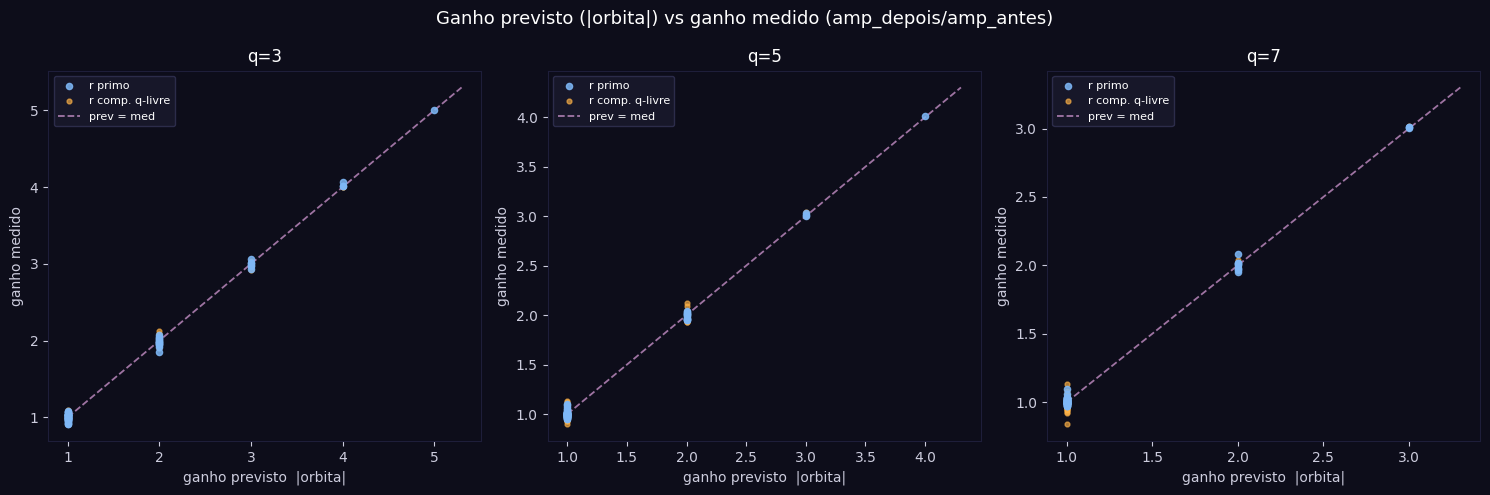

Figura salva: fat_log2_scatter_ganho.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Ganho previsto (|orbita|) vs ganho medido (amp_depois/amp_antes)',
             color='white', fontsize=13)

for ax, q in zip(axes, PRIMOS_TESTE):
    ax.set_facecolor(BG)
    sub   = df[df['q'] == q].dropna(subset=['razao'])
    mp    = sub['primo_r'].values
    mc    = ~mp

    ax.scatter(sub[mp]['g_prev'], sub[mp]['g_med'],
               color=C_ORIG,  s=20, alpha=0.85, label='r primo',          zorder=3)
    ax.scatter(sub[mc]['g_prev'], sub[mc]['g_med'],
               color=C_FONTE, s=12, alpha=0.65, label='r comp. q-livre',  zorder=2)

    gmax = sub['g_prev'].max() + 0.3
    ax.plot([1, gmax], [1, gmax], '--', color=C_PREV, lw=1.3, alpha=0.7,
            label='prev = med')

    ax.set_title(f'q={q}', color='white', fontsize=12)
    ax.set_xlabel('ganho previsto  |orbita|', color=C_TEXT)
    ax.set_ylabel('ganho medido', color=C_TEXT)
    ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
    ax.tick_params(colors=C_TEXT)
    for s in ax.spines.values():
        s.set_edgecolor(C_GRID)

plt.tight_layout()
plt.savefig('fat_log2_scatter_ganho.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: fat_log2_scatter_ganho.png')


## 6. Zoom nas maiores órbitas (q = 3)

Para as 8 maiores órbitas de $q=3$, mostramos a região espectral em torno de $f_r$
**antes** (azul) e **depois** (vermelho) da remoção.

A linha tracejada branca marca $f_r$. O pico vermelho deve ser
$\approx |\mathcal{O}_r|\times$ maior que o pico azul.
O título de cada painel mostra a razão medida.


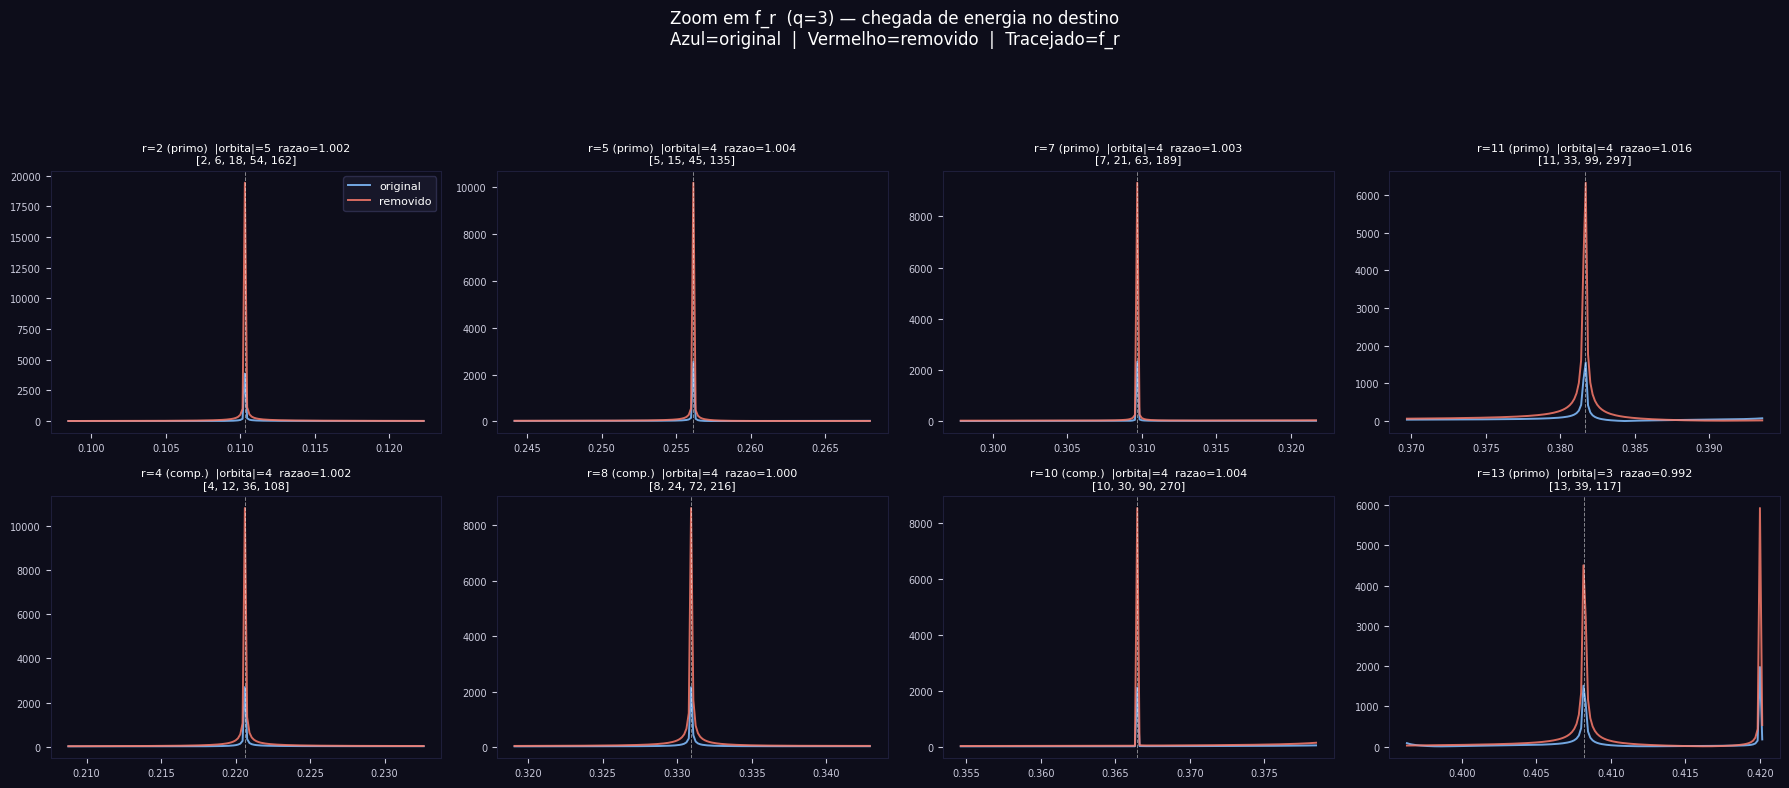

Figura salva: fat_log2_zoom_orbitas.png


In [6]:
q_zoom  = 3
orbs_z  = orbitas_q(q_zoom, N)
F_rem_z = espectros_rem[q_zoom]

# 8 maiores orbitas, priorizando primos como atratores
top8 = sorted(orbs_z.items(),
              key=lambda x: (-len(x[1]), -int(isprime(x[0]))))[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor(BG)
fig.suptitle(
    f'Zoom em f_r  (q={q_zoom}) — chegada de energia no destino\n'
    'Azul=original  |  Vermelho=removido  |  Tracejado=f_r',
    color='white', fontsize=12
)

for ax, (r, orbit) in zip(axes.flat, top8):
    ax.set_facecolor(BG)
    f_r   = f_de_log(math.log(r))
    fspan = 0.012
    mask  = (freqs > f_r - fspan) & (freqs < f_r + fspan)

    ax.plot(freqs[mask], F_log[mask],    color=C_ORIG, lw=1.4, alpha=0.9, label='original')
    ax.plot(freqs[mask], F_rem_z[mask],  color=C_REM,  lw=1.4, alpha=0.85, label='removido')
    ax.axvline(f_r, color='white', lw=0.7, ls='--', alpha=0.5)

    tipo  = 'primo' if isprime(r) else 'comp.'
    sub_r = df[(df['q'] == q_zoom) & (df['r'] == r)]['razao'].values
    rz    = f'{sub_r[0]:.3f}' if len(sub_r) > 0 else 'n/a'

    ax.set_title(
        f'r={r} ({tipo})  |orbita|={len(orbit)}  razao={rz}\n{orbit}',
        color='white', fontsize=8
    )
    ax.tick_params(colors=C_TEXT, labelsize=7)
    for s in ax.spines.values():
        s.set_edgecolor(C_GRID)

axes[0][0].legend(facecolor='#1A1A2E', edgecolor='#333355',
                  labelcolor='white', fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('fat_log2_zoom_orbitas.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: fat_log2_zoom_orbitas.png')


## 7. Espectro completo — origens e destinos marcados

Espectro antes (azul) e depois (vermelho) da remoção para cada primo $q$.

- Linhas **laranjas finas**: posições de **origem** — $f_m$ para múltiplos de $q$ com $a \geq 1$
- Linhas **verdes finas**: posições de **destino** — $f_r$ para $q$-livres com $|\mathcal{O}_r| \geq 2$

Espera-se: origens *esvaziam* no vermelho, destinos *crescem*.


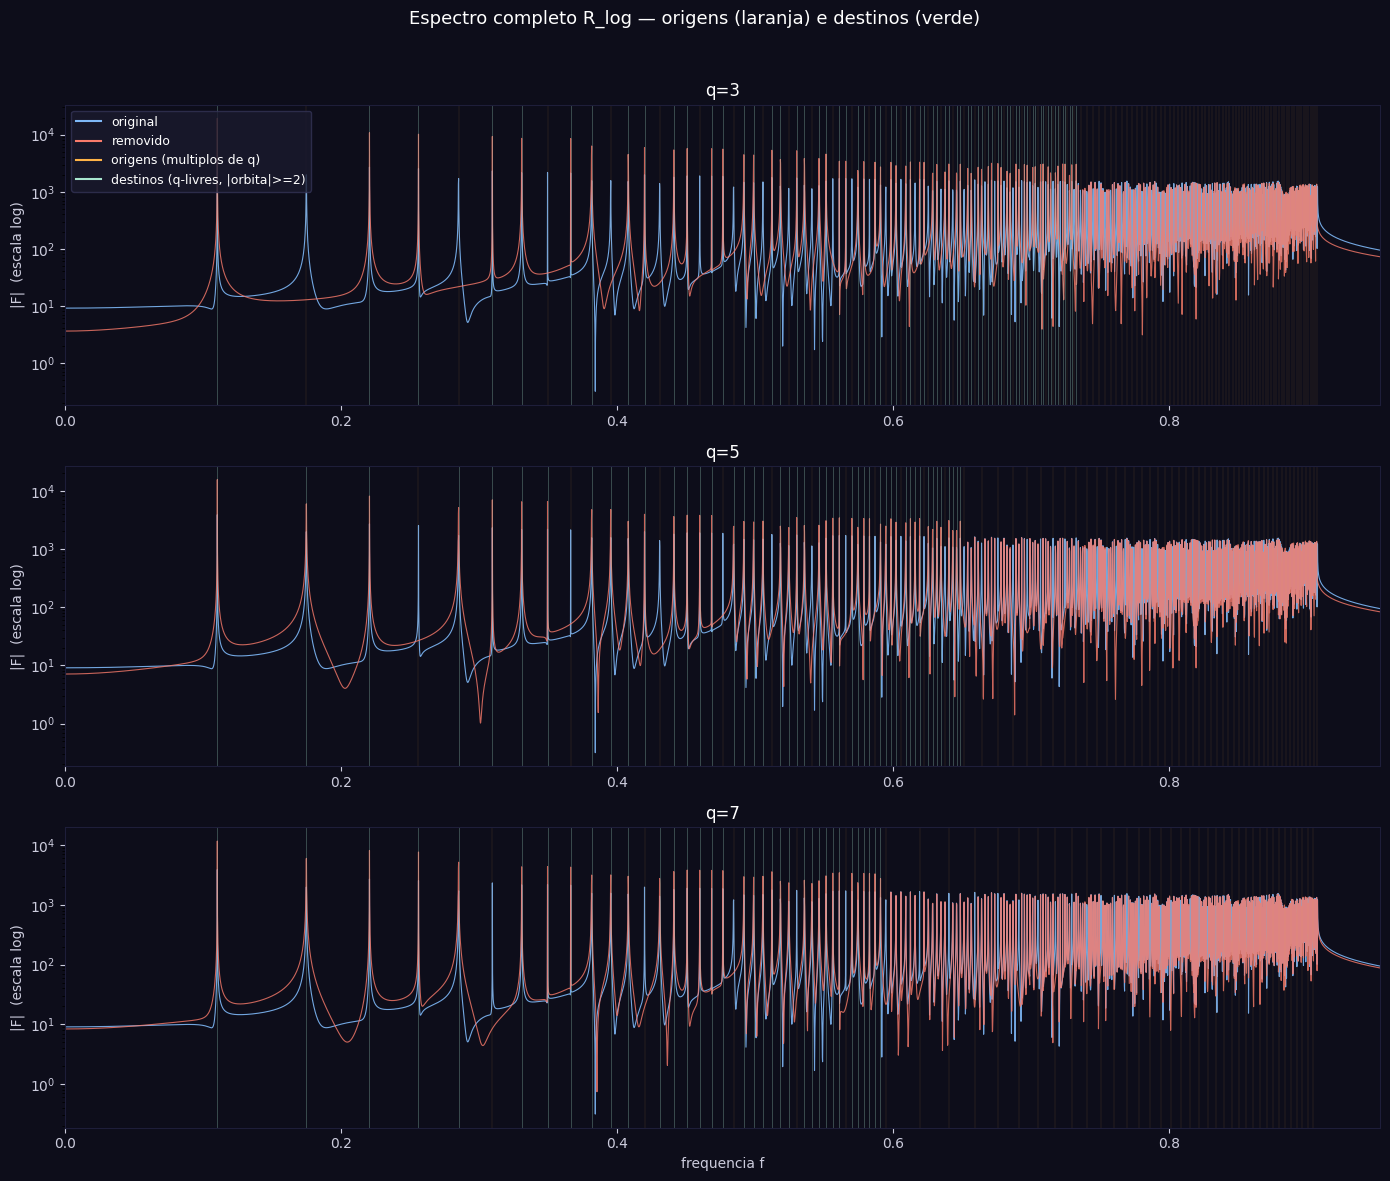

Figura salva: fat_log2_espectro_completo.png


In [7]:
from matplotlib.lines import Line2D

f_lim     = f_de_log(math.log(N)) * 1.05
mask_full = freqs <= f_lim

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.patch.set_facecolor(BG)
fig.suptitle('Espectro completo R_log — origens (laranja) e destinos (verde)',
             color='white', fontsize=13)

for ax, q in zip(axes, PRIMOS_TESTE):
    ax.set_facecolor(BG)
    F_rem = espectros_rem[q]
    orbs  = orbitas_q(q, N)

    ax.semilogy(freqs[mask_full], F_log[mask_full],
                color=C_ORIG, lw=0.8, alpha=0.9, label='original')
    ax.semilogy(freqs[mask_full], F_rem[mask_full],
                color=C_REM,  lw=0.8, alpha=0.8, label='removido')

    # Linhas de origem: multiplos de q com a >= 1
    for m in range(2, N + 1):
        if m % q == 0:
            fm = f_de_log(math.log(m))
            if fm <= f_lim:
                ax.axvline(fm, color=C_FONTE, lw=0.3, alpha=0.25)

    # Linhas de destino: q-livres com |orbita| >= 2
    for r, orb in orbs.items():
        if len(orb) >= 2:
            fr = f_de_log(math.log(r))
            if fr <= f_lim:
                ax.axvline(fr, color=C_DEST, lw=0.5, alpha=0.40)

    ax.set_title(f'q={q}', color='white')
    ax.set_ylabel('|F|  (escala log)', color=C_TEXT)
    ax.tick_params(colors=C_TEXT)
    ax.set_xlim(0, f_lim)
    for s in ax.spines.values():
        s.set_edgecolor(C_GRID)

handles = [
    Line2D([0],[0], color=C_ORIG,  lw=1.5, label='original'),
    Line2D([0],[0], color=C_REM,   lw=1.5, label='removido'),
    Line2D([0],[0], color=C_FONTE, lw=1.5, label='origens (multiplos de q)'),
    Line2D([0],[0], color=C_DEST,  lw=1.5, label='destinos (q-livres, |orbita|>=2)'),
]
axes[0].legend(handles=handles, facecolor='#1A1A2E', edgecolor='#333355',
               labelcolor='white', fontsize=9)
axes[-1].set_xlabel('frequencia f', color=C_TEXT)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fat_log2_espectro_completo.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figura salva: fat_log2_espectro_completo.png')


## 8. Verificação de energia — norma L² e redistribuição espectral

A operação **não é isométrica** por dois motivos independentes:

1. **Descarte:** potências puras $q^a$ (ex: $3, 9, 27, \ldots$ para $q=3$) somem do sinal.

2. **Amplificação por concentração:** cada membro $rq^a$ passa de amplitude
   $1/\sqrt{\log(rq^a)}$ para $1/\sqrt{\log r}$.
   Como $\log r < \log(rq^a)$, a amplitude **sobe** ao convergir para o destino.

Portanto a norma $L^2$ do sinal deve **crescer** após a remoção
(exceto pela pequena perda dos descartados).

Aqui medimos:
- Norma $L^2$ antes e depois
- Potência espectral nas posições de **origem** vs **destino**
- Fração da perda nas origens capturada pelos destinos


In [8]:
print('=== Norma L2 ===')
norma_orig = np.sqrt(np.mean(R_log**2))
print(f'  Original : {norma_orig:.6f}')

for q in PRIMOS_TESTE:
    R_rem  = sinais_rem[q]
    n_rem  = np.sqrt(np.mean(R_rem**2))
    ratio  = n_rem / norma_orig
    pp     = [q**k for k in range(1, 30) if 2 <= q**k <= N]
    print(f'  q={q}      : {n_rem:.6f}  ratio={ratio:.5f}'
          f'  | descartados (pot. puras): {pp}')

print()
print('=== Potencia espectral: origens vs destinos ===')
for q in PRIMOS_TESTE:
    F_rem   = espectros_rem[q]
    orbs    = orbitas_q(q, N)

    orig_ms = [m for m in range(2, N+1) if m % q == 0]
    P_oa    = sum(amp_em_f(F_log, f_de_log(math.log(m)))**2 for m in orig_ms)
    P_od    = sum(amp_em_f(F_rem,  f_de_log(math.log(m)))**2 for m in orig_ms)

    dest_rs = [r for r, o in orbs.items() if len(o) >= 2]
    P_da    = sum(amp_em_f(F_log, f_de_log(math.log(r)))**2 for r in dest_rs)
    P_dd    = sum(amp_em_f(F_rem,  f_de_log(math.log(r)))**2 for r in dest_rs)

    d_orig = P_od - P_oa
    d_dest = P_dd - P_da

    print(f'\nq={q}:')
    print(f'  Origens  antes={P_oa:.2f}  depois={P_od:.2f}  delta={d_orig:+.2f}')
    print(f'  Destinos antes={P_da:.2f}  depois={P_dd:.2f}  delta={d_dest:+.2f}')
    if d_orig < 0 and d_dest != 0:
        frac = d_dest / (-d_orig)
        print(f'  Fracao da perda nas origens capturada pelos destinos: {frac:.4f}')


=== Norma L2 ===
  Original : 5.809768
  q=3      : 9.917109  ratio=1.70697  | descartados (pot. puras): [3, 9, 27, 81, 243]
  q=5      : 8.497532  ratio=1.46263  | descartados (pot. puras): [5, 25, 125]
  q=7      : 7.805307  ratio=1.34348  | descartados (pot. puras): [7, 49]

=== Potencia espectral: origens vs destinos ===

q=3:
  Origens  antes=172798383.56  depois=13051843.98  delta=-159746539.58
  Destinos antes=173038418.52  depois=1570004356.22  delta=+1396965937.69
  Fracao da perda nas origens capturada pelos destinos: 8.7449

q=5:
  Origens  antes=111938471.52  depois=9293095.42  delta=-102645376.09
  Destinos antes=134571030.03  depois=891481742.01  delta=+756910711.97
  Fracao da perda nas origens capturada pelos destinos: 7.3740

q=7:
  Origens  antes=77999723.05  depois=3293738.05  delta=-74705984.99
  Destinos antes=115491303.88  depois=642239224.52  delta=+526747920.64
  Fracao da perda nas origens capturada pelos destinos: 7.0509


## 9. Exportar resultados

In [9]:
# Salvar espectros para notebooks futuros
with open('espectros_log2.pkl', 'wb') as f:
    pickle.dump({
        'freqs'           : freqs,
        'N'               : N,
        'T_MAX'           : T_MAX,
        'F_log'           : F_log,
        'espectros_rem'   : espectros_rem,
        'PRIMOS_TESTE'    : PRIMOS_TESTE,
        'df_ganho'        : df,
    }, f)

# Empacotar tudo
ARQUIVOS = [
    'fat_log2_ganho_destino.csv',
    'fat_log2_scatter_ganho.png',
    'fat_log2_zoom_orbitas.png',
    'fat_log2_espectro_completo.png',
    'espectros_log2.pkl',
]
with zipfile.ZipFile('exp_fat_log2_resultados.zip', 'w') as zf:
    for arq in ARQUIVOS:
        if os.path.exists(arq):
            zf.write(arq)

print('Pacote: exp_fat_log2_resultados.zip')
for arq in ARQUIVOS:
    status = 'OK      ' if os.path.exists(arq) else 'FALTANDO'
    print(f'  [{status}] {arq}')


Pacote: exp_fat_log2_resultados.zip
  [OK      ] fat_log2_ganho_destino.csv
  [OK      ] fat_log2_scatter_ganho.png
  [OK      ] fat_log2_zoom_orbitas.png
  [OK      ] fat_log2_espectro_completo.png
  [OK      ] espectros_log2.pkl
